# 04. Análise Exploratória — Regionalização e Diversidade de Gêneros (H2, H5)

## Objetivo deste notebook

Expansão internacional do catálogo (`country`) e diversidade de gêneros (`listed_in`),
ambas usando a metodologia de explode definida em `02_data_cleaning.ipynb`.

## Hipóteses cobertas

| ID | Pergunta de Negócio | Métrica Operacional |
|---|---|---|
| **H2** | O catálogo reflete expansão internacional? | % de aparições fora dos EUA por ano, excluindo `'Unknown'` |
| **H5** | Como evoluiu a diversidade de gêneros? | (1) Nº de gêneros únicos por ano. (2) % de participação do Top 5 histórico fixo |

## Ajuste metodológico (pós-auditoria de robustez em H4)

Mesmo filtro `MIN_YEARLY_VOLUME >= 100` aplicado em `03_eda_catalogo.ipynb` é replicado
aqui, restringindo as séries temporais a 2016–2020. Anos anteriores tinham volume
insuficiente (1–82 títulos/ano), produzindo percentuais instáveis (ex: 0% a 100% de
internacionalização de um ano para o outro).

## Premissas herdadas

- `country == 'Unknown'` excluído do cálculo de H2 (numerador e denominador).
- Top 5 de H5 são fixos, calculados sobre o histórico completo do catálogo.
- Referência temporal: `year_added`, nunca `release_year`.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('dark_background')

NETFLIX_RED = "#E50914"
SILVER = "#B3B3B3"
BG_COLOR = "#141414"
GRID_COLOR = "#2A2A2A"
TEXT_COLOR = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor": BG_COLOR, "savefig.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR, "axes.labelcolor": TEXT_COLOR, "axes.titlecolor": TEXT_COLOR,
    "text.color": TEXT_COLOR, "xtick.color": TEXT_COLOR, "ytick.color": TEXT_COLOR,
    "grid.color": GRID_COLOR, "grid.alpha": 0.5, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.figsize": (12, 6), "legend.frameon": False,
})
df = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_titles_clean.csv')
df['date_added_clean'] = pd.to_datetime(df['date_added_clean'])

df_countries = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_countries_exploded.csv')
df_genres = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_genres_exploded.csv')

print(f"df_countries: {len(df_countries)} linhas | {df_countries['country'].nunique()} países únicos")
print(f"df_genres: {len(df_genres)} linhas | {df_genres['genre'].nunique()} gêneros únicos")

df_countries: 10843 linhas | 123 países únicos
df_genres: 19323 linhas | 42 gêneros únicos


In [12]:
MIN_YEARLY_VOLUME = 100

yearly_totals_check = df.dropna(subset=['date_added_clean']).copy()
yearly_totals_check = yearly_totals_check[yearly_totals_check['year_added'] <= 2020]
yearly_totals_check = yearly_totals_check.groupby('year_added').size()

years_valid = yearly_totals_check[yearly_totals_check >= MIN_YEARLY_VOLUME].index
print(f"Anos considerados robustos: {sorted(years_valid)}")

Anos considerados robustos: [2016.0, 2017.0, 2018.0, 2019.0, 2020.0]


**Aplicação da regra de H2:** registros com `country == 'Unknown'` são filtrados antes de
qualquer cálculo de proporção, conforme decisão registrada em `02_data_cleaning.ipynb`.

Aparições usadas no cálculo de H2: 8357 de 10843 totais (excluídos: Unknown + anos de baixo volume)


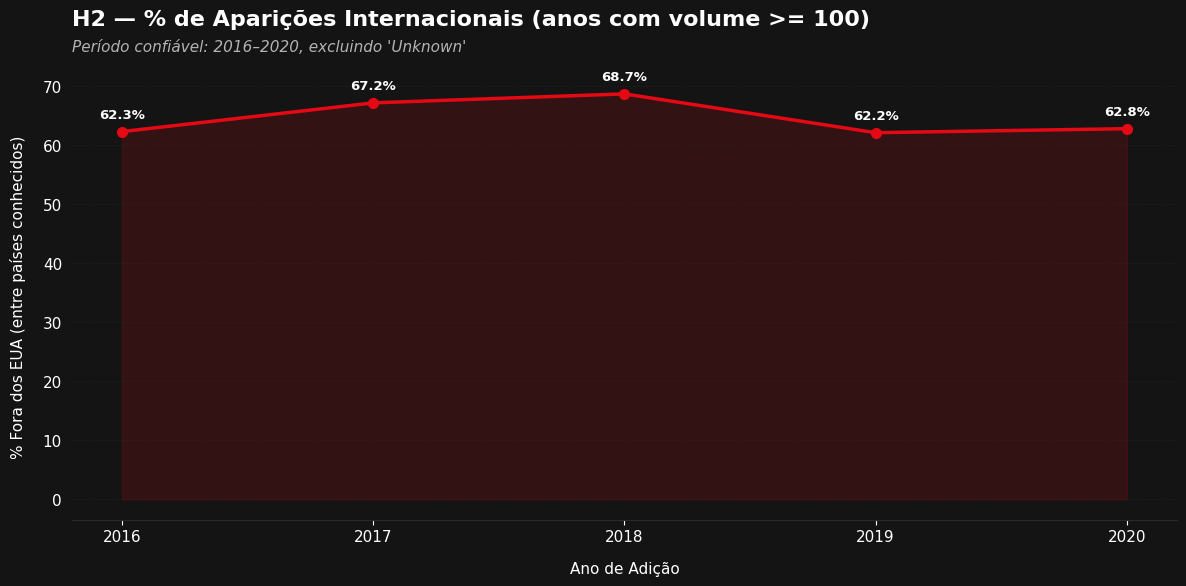


% internacional em 2016: 62.3%
% internacional em 2020: 62.8%


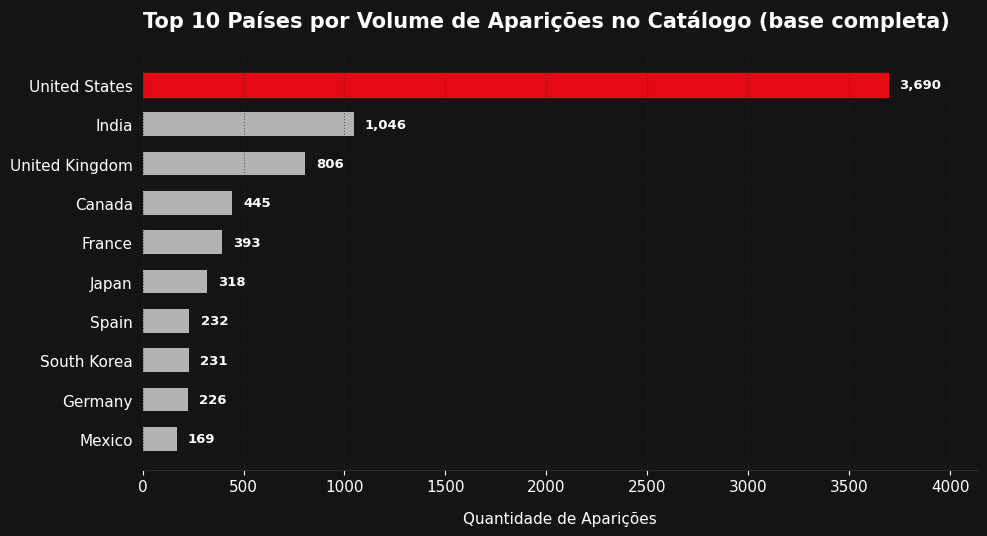

In [16]:
df_country_valid = df_countries[
    (df_countries['country'] != 'Unknown') &
    (df_countries['year_added'].isin(years_valid))
].copy()

n_total_countries = len(df_countries)
n_used = len(df_country_valid)
print(f"Aparições usadas no cálculo de H2: {n_used} de {n_total_countries} totais (excluídos: Unknown + anos de baixo volume)")

df_country_valid['is_international'] = df_country_valid['country'] != 'United States'
intl_share_by_year = df_country_valid.groupby('year_added')['is_international'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

ax.plot(intl_share_by_year.index, intl_share_by_year.values,
        marker='o', markersize=7, linewidth=2.5, color=NETFLIX_RED)
ax.fill_between(intl_share_by_year.index, intl_share_by_year.values, color=NETFLIX_RED, alpha=0.15)

for year, val in zip(intl_share_by_year.index, intl_share_by_year.values):
    ax.annotate(f"{val:.1f}%", (year, val), textcoords="offset points", xytext=(0, 10),
                ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

ax.set_title(f"H2 — % de Aparições Internacionais (anos com volume >= {MIN_YEARLY_VOLUME})", loc='left', pad=35, fontsize=16)
ax.text(0, 1.05, f"Período confiável: {min(years_valid):.0f}–2020, excluindo 'Unknown'",
        transform=ax.transAxes, color=SILVER, fontsize=11, style='italic')

ax.set_xlabel("Ano de Adição", labelpad=12)
ax.set_ylabel("% Fora dos EUA (entre países conhecidos)", labelpad=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"\n% internacional em {intl_share_by_year.index.min():.0f}: {intl_share_by_year.iloc[0]:.1f}%")
print(f"% internacional em 2020: {intl_share_by_year.iloc[-1]:.1f}%")

top_countries = df_countries[df_countries['country'] != 'Unknown']['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=SILVER, height=0.6)
bars[-1].set_color(NETFLIX_RED)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:,}', xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(8, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9.5, fontweight='bold', color=TEXT_COLOR)

ax.set_title("Top 10 Países por Volume de Aparições no Catálogo (base completa)", pad=20, loc='left', fontsize=15)
ax.set_xlabel("Quantidade de Aparições", labelpad=12)
ax.set_xlim(0, max(top_countries.values) * 1.12)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRID_COLOR)
ax.tick_params(left=False)
ax.xaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Top 5 gêneros históricos (baseline fixo, base completa): ['International Movies', 'Dramas', 'Comedies', 'International TV Shows', 'Documentaries']


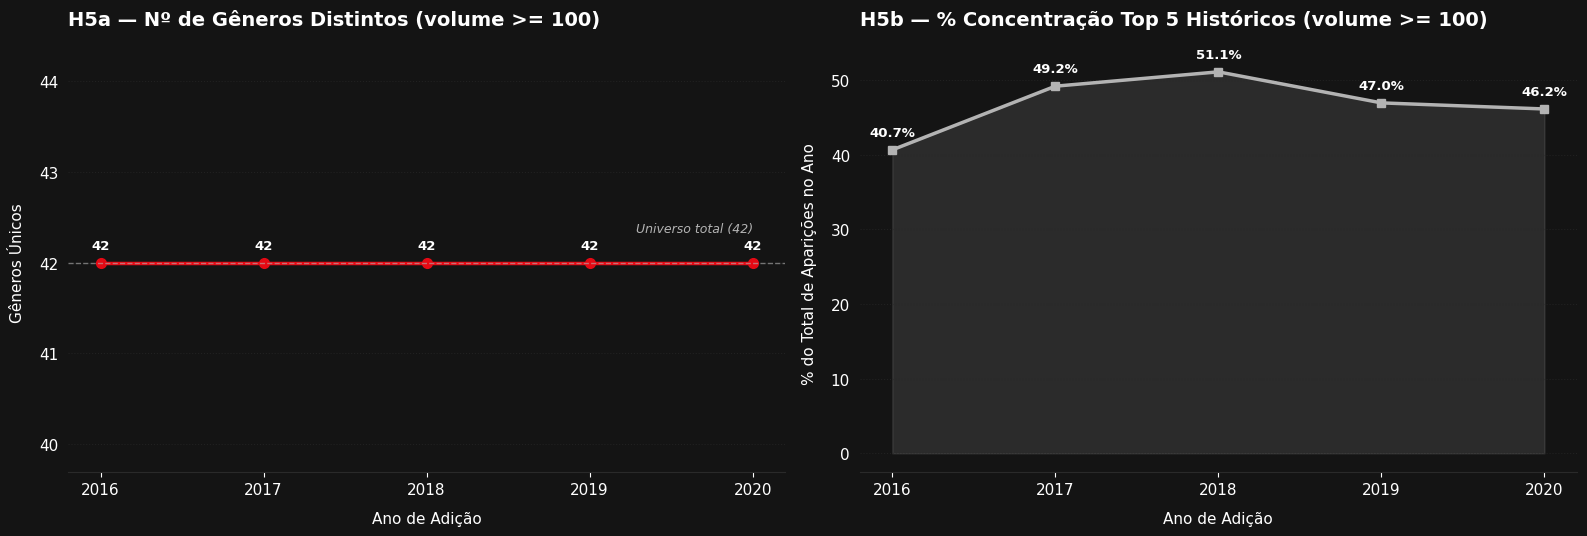


Gêneros únicos por ano (2016-2020): min=42, max=42 (universo total: 42)
Concentração Top 5 — 2016: 40.7% | 2020: 46.2%


In [17]:
df_genre_valid = df_genres[df_genres['year_added'].isin(years_valid)].copy()

genre_diversity_by_year = df_genre_valid.groupby('year_added')['genre'].nunique()

top5_genres_fixed = df_genres['genre'].value_counts().head(5).index.tolist()
print("Top 5 gêneros históricos (baseline fixo, base completa):", top5_genres_fixed)

df_genre_valid['is_top5'] = df_genre_valid['genre'].isin(top5_genres_fixed)
top5_share_by_year = df_genre_valid.groupby('year_added')['is_top5'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), facecolor=BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

axes[0].plot(genre_diversity_by_year.index, genre_diversity_by_year.values,
             marker='o', markersize=7, color=NETFLIX_RED, linewidth=2.5)
for year, val in zip(genre_diversity_by_year.index, genre_diversity_by_year.values):
    axes[0].annotate(f"{val}", (year, val), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

axes[0].set_title(f"H5a — Nº de Gêneros Distintos (volume >= {MIN_YEARLY_VOLUME})", pad=20, loc='left', fontsize=14)
axes[0].set_xlabel("Ano de Adição", labelpad=10)
axes[0].set_ylabel("Gêneros Únicos", labelpad=10)
axes[0].axhline(y=42, color=SILVER, linestyle='--', linewidth=1, alpha=0.6)
axes[0].text(genre_diversity_by_year.index.max(), 42.3, ' Universo total (42)',
             color=SILVER, fontsize=9, va='bottom', ha='right', style='italic')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[0].spines['left'].set_visible(False)
axes[0].tick_params(left=False, labelleft=True)
axes[0].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

axes[1].plot(top5_share_by_year.index, top5_share_by_year.values,
             marker='s', markersize=6, color=SILVER, linewidth=2.5)
axes[1].fill_between(top5_share_by_year.index, top5_share_by_year.values, color=SILVER, alpha=0.15)
for year, val in zip(top5_share_by_year.index, top5_share_by_year.values):
    axes[1].annotate(f"{val:.1f}%", (year, val), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

axes[1].set_title(f"H5b — % Concentração Top 5 Históricos (volume >= {MIN_YEARLY_VOLUME})", pad=20, loc='left', fontsize=14)
axes[1].set_xlabel("Ano de Adição", labelpad=10)
axes[1].set_ylabel("% do Total de Aparições no Ano", labelpad=10)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False, labelleft=True)
axes[1].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"\nGêneros únicos por ano (2016-2020): min={genre_diversity_by_year.min()}, max={genre_diversity_by_year.max()} (universo total: 42)")
print(f"Concentração Top 5 — {top5_share_by_year.index.min():.0f}: {top5_share_by_year.iloc[0]:.1f}% | 2020: {top5_share_by_year.iloc[-1]:.1f}%")